In [292]:
#------------------------------------------------------------------------------------------------------------------------
# Project 1- Pass Impact Factor (PIF) analysis
# MAST 397 - Fall 2025
# Written by : Christina Supino (40298851)
#------------------------------------------------------------------------------------------------------------------------

In [293]:
#------------------------------------------------------------------------------------------------------------------------
#Short Description of code:
#The following jupyter notebook was used to analyze soccer passes of game 2 soccer data provided by Metrica and  helps answer the question "What makes for a good pass?".
#The Impact factor used is defined by PIF=x(Progression)+y(Time of Possession)+z(Third of Field).
#The variables x,y,z are weights and can be altered depending on what is seen to be the most beneficial in a pass.
#------------------------------------------------------------------------------------------------------------------------

In [294]:
# Standard imports
import sys, os
import seaborn as sns
import pandas as pd
pd.set_option("display.max_rows", 101)
pd.set_option("display.max_columns", 101)

import matplotlib.cm as cm
import matplotlib.pyplot as plt


In [295]:
# Import Metrica helper files
import Metrica_IO as mio
import Metrica_Viz as mviz

In [296]:
# Absolute path to sample-data folder
DATADIR = "/Users/christinasupino/sample-data/data"
game_id = 2

In [297]:
# read in the event data
events = mio.read_event_data(DATADIR,game_id)

In [298]:
# Count the number of each event type in the data
print( events['Type'].value_counts() )

Type
PASS              964
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: count, dtype: int64


In [299]:
#Unit conversion from metrica data units to meters
events = mio.to_metric_coordinates(events)

In [300]:
events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.00,-0.00,-10.60,-0.68
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,-7.42,-0.00,-6.36,19.04
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,-3.18,21.08,-20.14,14.96
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,-22.26,12.24,-25.44,-5.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Away,BALL LOST,INTERCEPTION,2,140122,5604.88,140183,5607.32,Player21,NaN,4.24,-18.36,-22.26,17.68
1931,Home,CHALLENGE,AERIAL-LOST,2,140180,5607.20,140180,5607.20,Player1,NaN,-20.14,13.60,NaN,NaN
1932,Away,CHALLENGE,AERIAL-LOST,2,140183,5607.32,140183,5607.32,Player24,NaN,-19.08,13.60,NaN,NaN
1933,Home,RECOVERY,NaN,2,140211,5608.44,140211,5608.44,Player12,NaN,-16.96,12.24,NaN,NaN


In [301]:
# Get events by team
home_events = events[events['Team']=='Home']
away_events = events[events['Team']=='Away']

# Frequency of each event type by team
home=home_events['Type'].value_counts()
away=away_events['Type'].value_counts()

In [302]:
home,away

(Type
 PASS              543
 CHALLENGE         160
 RECOVERY          135
 BALL LOST         120
 SET PIECE          34
 BALL OUT           27
 SHOT               13
 FAULT RECEIVED      9
 CARD                3
 Name: count, dtype: int64,
 Type
 PASS              421
 CHALLENGE         151
 BALL LOST         113
 RECOVERY          113
 SET PIECE          46
 BALL OUT           22
 SHOT               11
 FAULT RECEIVED     11
 CARD                3
 Name: count, dtype: int64)

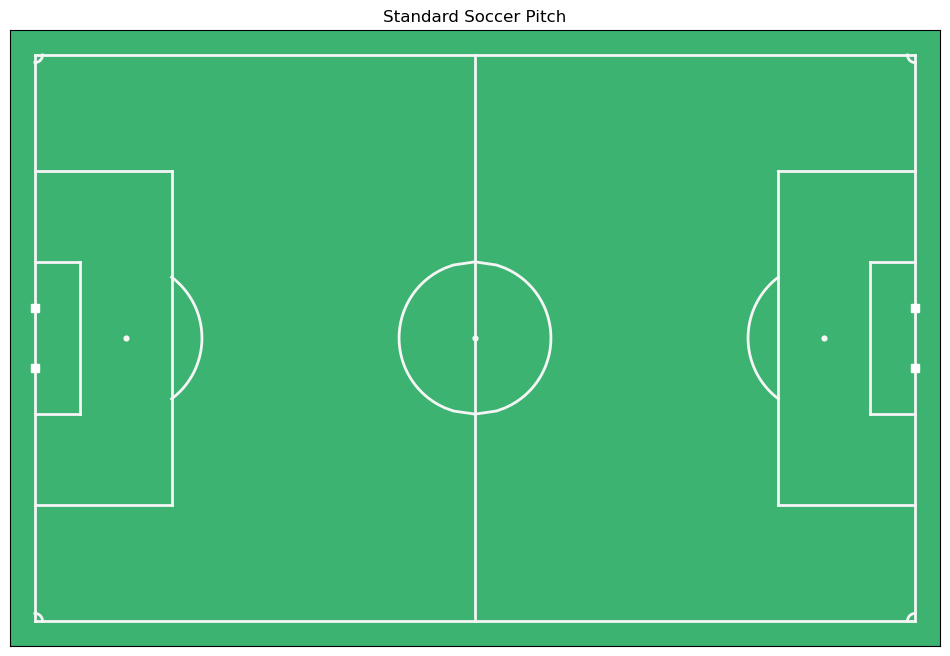

In [303]:
#Visual representation of a standard soccer pitch
ffig, ax = mviz.plot_pitch()
ax.set_title("Standard Soccer Pitch")
plt.show()

Reading team: home
Reading team: away


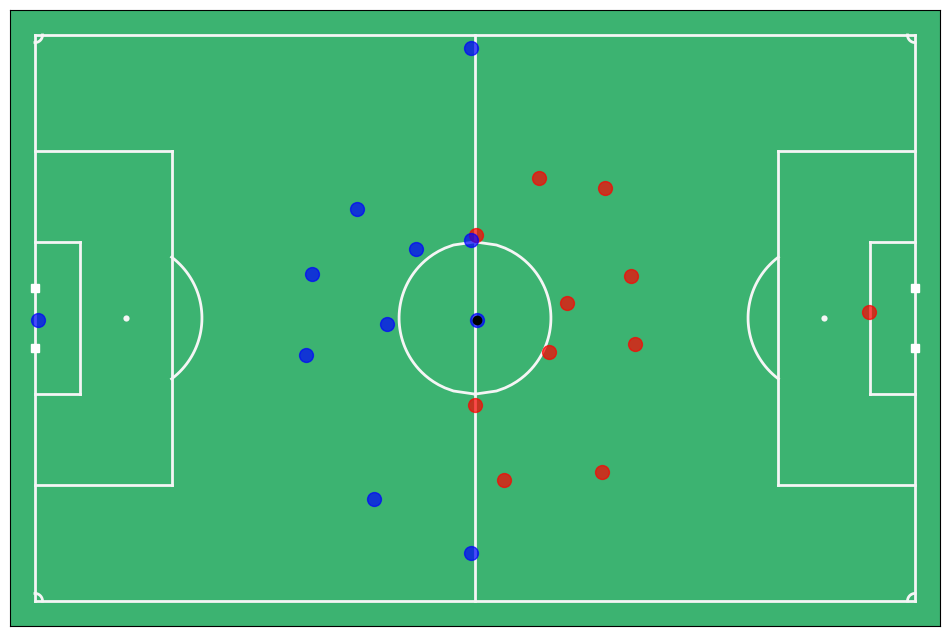

In [304]:
#Get tracking data by team
tracking_home = mio.tracking_data(DATADIR,game_id,'Home')
tracking_away = mio.tracking_data(DATADIR,game_id,'Away')

# Convert positions from metrica units to meters 
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


# Plot player positions at kick-off
KO_Frame = events.loc[0]['Start Frame']
fig,ax = mviz.plot_frame( tracking_home.loc[KO_Frame], tracking_away.loc[KO_Frame] )


In [305]:
#Create a seperate data set for passes only
passes = events.loc[events["Type"]=="PASS"]

#Output data set "passes"
passes

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.00,-0.00,-10.60,-0.68
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,-7.42,-0.00,-6.36,19.04
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,-3.18,21.08,-20.14,14.96
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,-22.26,12.24,-25.44,-5.44
5,Away,PASS,NaN,1,395,15.80,423,16.92,Player16,Player15,-25.44,-10.88,-24.38,-27.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914,Home,PASS,NaN,2,137209,5488.36,137221,5488.84,Player1,Player6,-9.54,12.24,-4.24,4.76
1915,Home,PASS,NaN,2,137263,5490.52,137303,5492.12,Player6,Player1,-4.24,12.24,-12.72,21.76
1916,Home,PASS,NaN,2,137303,5492.12,137332,5493.28,Player1,Player5,-12.72,21.76,-1.06,26.52
1917,Home,PASS,NaN,2,137334,5493.36,137359,5494.36,Player5,Player1,-1.06,26.52,-15.90,26.52


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/370079562.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_red = cm.get_cmap('Reds')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/370079562.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')


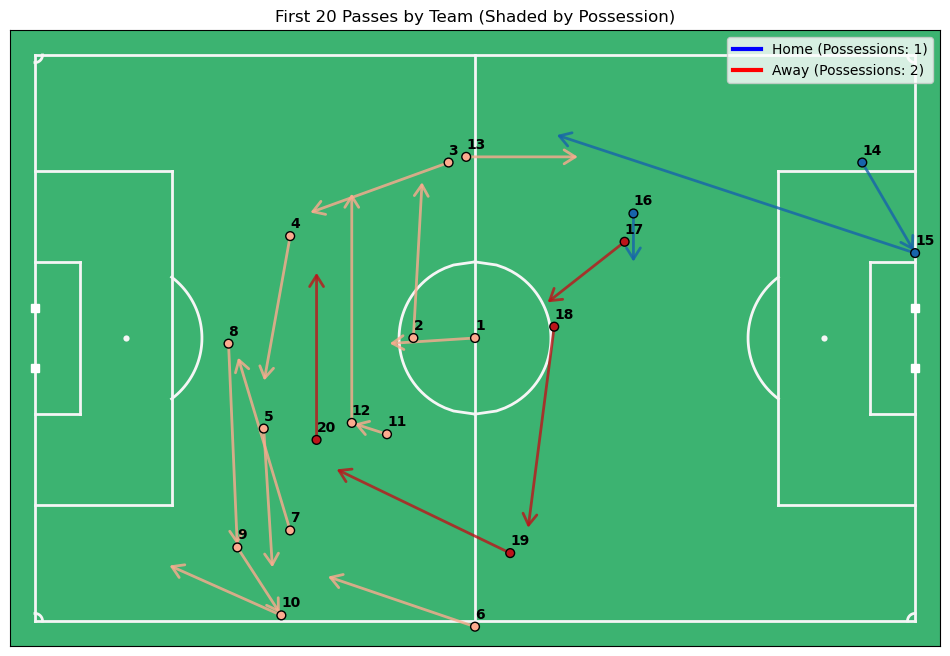

The following graph shows the first 20 passses,color coded by team and possession.As the number of possession  increase the darker the labeling of passing seqeunces.


In [322]:
#Plot first 20 passes of game by possession 

# Compute "Possession" for each team
#Posession is the grouping of frames that the team has the ball for until oponent steals

passes = passes.copy()
passes['Possession'] = (passes['Team'] != passes['Team'].shift(1)).cumsum()


# Consider first 20 passes
first20_passes = passes.head(20)


#Determine max number of possessions for each team
max_possession_home = first20_passes[first20_passes['Team']=='Home']['Possession'].max()
max_possession_away = first20_passes[first20_passes['Team']=='Away']['Possession'].max()

# Colormaps
cmap_red = cm.get_cmap('Reds')
cmap_blue = cm.get_cmap('Blues')

#Plot the field and label
fig, ax = mviz.plot_pitch()
ax.set_title("First 20 Passes by Team (Shaded by Possession)")

#Plot arrows and label passes
for i, (_, row) in enumerate(first20_passes.iterrows(), start=1):
    team = row['Team']
    
    if team == "Home":
        #make color get darker with increased possession counts
        possession_scaled = 0.3 + 0.5 * (row['Possession'] - 1) / max(1, max_possession_home-1)
        color = cmap_blue(possession_scaled)
    else: 
        possession_scaled = 0.3 + 0.5 * (row['Possession'] - 1) / max(1, max_possession_away-1)
        color = cmap_red(possession_scaled)

    # plot arrows
    ax.annotate("",
                xy=row[['End X', 'End Y']],
                xytext=row[['Start X', 'Start Y']],
                arrowprops=dict(arrowstyle="->,head_length=0.8,head_width=0.5",
                                color=color, lw=2, alpha=0.8),
                annotation_clip=False)
    
    # Label pass number
    ax.text(row['Start X'], row['Start Y']+1, str(i), color='black', fontsize=10, weight='bold')

# Plot start points 
for team in ["Home", "Away"]:
    team_passes = first20_passes[first20_passes['Team'] == team]
    if team == "Home":
        colors = [cmap_blue(0.3 + 0.5 * (p-1)/max(1,max_possession_home-1)) for p in team_passes['Possession']]
    else:
        colors = [cmap_red(0.3 + 0.5 * (p-1)/max(1,max_possession_away-1)) for p in team_passes['Possession']]
    ax.scatter(team_passes['Start X'], team_passes['Start Y'],
               c=colors, s=40, edgecolors='k', zorder=5)

#Legend for team colors + possession counts
handles, labels = [], []
for team, base_color in {"Home": "blue", "Away": "red"}.items():
    count = first20_passes[first20_passes['Team'] == team]['Possession'].nunique()
    handles.append(plt.Line2D([0],[0], color=base_color, lw=3))
    labels.append(f"{team} (Possessions: {count})")
ax.legend(handles, labels, loc='upper right')

plt.show()
print("The following graph shows the first 20 passses,color coded by team and possession.As the number of possession  increase the darker the labeling of passing seqeunces.")


In [307]:
# PIF Factor #1: Location of Pass
#What third is the play occuring within?

goal_box = 11
pitch_length = 105  # total pitch length in meters

# Filter out passes starting inside goal box 
def outside_goal_box(row):
    half_pitch = pitch_length / 2
    if row['Team'] == "Home" and row['Start X'] <= -half_pitch + goal_box:
        return False
    if row['Team'] == "Away" and row['Start X'] >= half_pitch - goal_box:
        return False
    return True

passes_filtered = passes[passes.apply(outside_goal_box, axis=1)].copy()

# Adjust sides at half-time so all attacks are left → right
def adjust_x(row):
    if row['Period'] == 2:
        return -row['Start X'], -row['End X']
    else:
        return row['Start X'], row['End X']

passes_filtered[['Start_X_adj', 'End_X_adj']] = passes.apply(lambda r: adjust_x(r), axis=1, result_type='expand')

# Assign Third-of-Field based on adjusted coordinates (center = 0)
def field_third_centered(x):
    third_width = pitch_length / 6  # because pitch runs -52.5 to +52.5
    if x < -third_width:
        return "Defensive"
    elif x < third_width:
        return "Middle"
    else:
        return "Attacking"

passes_filtered['Third'] = passes_filtered['Start_X_adj'].apply(field_third_centered)

# Assign "Bonus" for thirds
third_bonus = {"Defensive": 1.5, "Middle": 1.4, "Attacking": 1.5}
passes_filtered['Third_Bonus'] = passes_filtered['Third'].map(third_bonus)


In [308]:
# PIF FACTOR #2: Progressiveness of the ball
# How far has the ball travelled forward/backward?

def prog_score_centered(row):
    # Use adjusted coordinates so all attacks are left->right
    dx = row['End_X_adj'] - row['Start_X_adj']

    if dx > 0:
        # Forward pass: full reward
        return dx / 10  
    else:
        # Backward pass: still give some credit
        # Own half = Start_X_adj < 0
        if row['Start_X_adj'] < 0:
            # Defensive half: recycling under pressure
            return abs(dx) / 20
        else:
            # Attacking half: can set up chances
            return abs(dx) / 15

# Apply to all passes
passes_filtered['delta_x'] = passes_filtered['End_X_adj'] - passes_filtered['Start_X_adj']
passes_filtered['Prog_Score'] = passes_filtered.apply(prog_score_centered, axis=1)



In [309]:
#PIF FACTOR #3: Possession of the ball
# How long has the team been controlling the play?

events = events.copy()

# Ensure Possession column exists
if 'Possession' not in events.columns:
    events['Possession'] = (events['Team'] != events['Team'].shift(1)).cumsum()

# STEP 1: Compute possession durations
possession_times = (
    events.groupby('Possession')['Start Time [s]']
    .agg(['min', 'max'])
    .reset_index()
)
possession_times['duration'] = possession_times['max'] - possession_times['min']

# STEP 2: Merge duration into passes safely
if 'Possession' not in passes.columns:
    passes['Possession'] = (passes_filtered['Team'] != passes_filtered['Team'].shift(1)).cumsum()

# Drop any existing 'duration' column in passes to avoid merge conflicts
if 'duration' in passes.columns:
    passes_filtered = passes_filtered.drop(columns=['duration'])

passes_filtered = passes_filtered.merge(
    possession_times[['Possession', 'duration']],
    on='Possession',
    how='left'
)

# STEP 3: Time bonus
# Backward-compatible: give bonus only if possession duration > 5s
passes_filtered['Time_Bonus'] = passes_filtered['duration'].apply(lambda d: d/5 if pd.notna(d) and d > 5 else 0)



In [310]:
#Combine the factors using a normalize approach for the PIF formula defined as: PIF=x(Progression)+y(Time of Possession)+z(Third of Field).

# Normalize each factor to 0–1 
passes_filtered['Prog_Score_N'] = (
    passes_filtered['Prog_Score'] - passes_filtered['Prog_Score'].min()
) / (passes_filtered['Prog_Score'].max() - passes_filtered['Prog_Score'].min())

passes_filtered['Time_Bonus_N'] = (
    passes_filtered['Time_Bonus'] - passes_filtered['Time_Bonus'].min()
) / (passes_filtered['Time_Bonus'].max() - passes_filtered['Time_Bonus'].min())

passes_filtered['Third_Bonus_N'] = (
    passes_filtered['Third_Bonus'] - passes_filtered['Third_Bonus'].min()
) / (passes_filtered['Third_Bonus'].max() - passes_filtered['Third_Bonus'].min())

# Weighted sum (x,y,z)
weight_prog = 0.4
weight_time = 0.3
weight_third = 0.3

# Combination of factors
passes_filtered['PIF_Raw'] = (
    weight_prog * passes_filtered['Prog_Score_N'] +
    weight_time * passes_filtered['Time_Bonus_N'] +
    weight_third * passes_filtered['Third_Bonus_N']
)

# Rescale to 1–5(5= best ,1 =worst)
pif_min, pif_max = passes_filtered['PIF_Raw'].min(), passes_filtered['PIF_Raw'].max()
passes_filtered['PIF_Scaled'] = ((passes_filtered['PIF_Raw'] - pif_min) / (pif_max - pif_min)) * 4 + 1

# Check 
passes_filtered['PIF_Scaled'].describe()


count    941.000000
mean       2.177491
std        0.928472
min        1.000000
25%        1.296296
50%        1.876168
75%        2.968254
max        5.000000
Name: PIF_Scaled, dtype: float64

In [311]:
#Let's look at the top passes of game 2 based on our definition of PIF.

# Sort passes by PIF_Scaled descending
top_passes = passes_filtered.sort_values('PIF_Scaled', ascending=False)

# Keep top 10 passes
top_passes = top_passes.head(10)

#Display 
top_passes = top_passes[['Team', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y', 'PIF_Raw', 'PIF_Scaled']]
top_passes


,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
786,Away,Player25,Player23,39.22,4.08,-18.02,-14.28,0.700000,5.000000
940,Away,Player25,Player21,39.22,-0.00,14.84,-20.40,0.667267,4.812952
49,Away,Player25,Player23,-49.82,-0.00,2.12,14.28,0.662963,4.788360
118,Home,Player3,Player11,36.04,-21.08,48.76,0.68,0.662318,4.784675
444,Away,Player25,Player20,-46.64,5.44,3.18,-3.40,0.648148,4.703704
803,Away,Player25,Player24,38.16,8.16,-11.66,28.56,0.648148,4.703704
115,Home,Player7,Player4,29.68,-24.48,40.28,-27.88,0.647503,4.700019
119,Home,Player5,Player2,19.08,25.16,26.50,26.52,0.625281,4.573035
113,Home,Player6,Player4,31.80,-29.92,37.10,-27.20,0.610466,4.488379
114,Home,Player4,Player7,37.10,-27.20,29.68,-24.48,0.607997,4.474269


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/94634668.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap('Blues')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/94634668.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap('Reds')


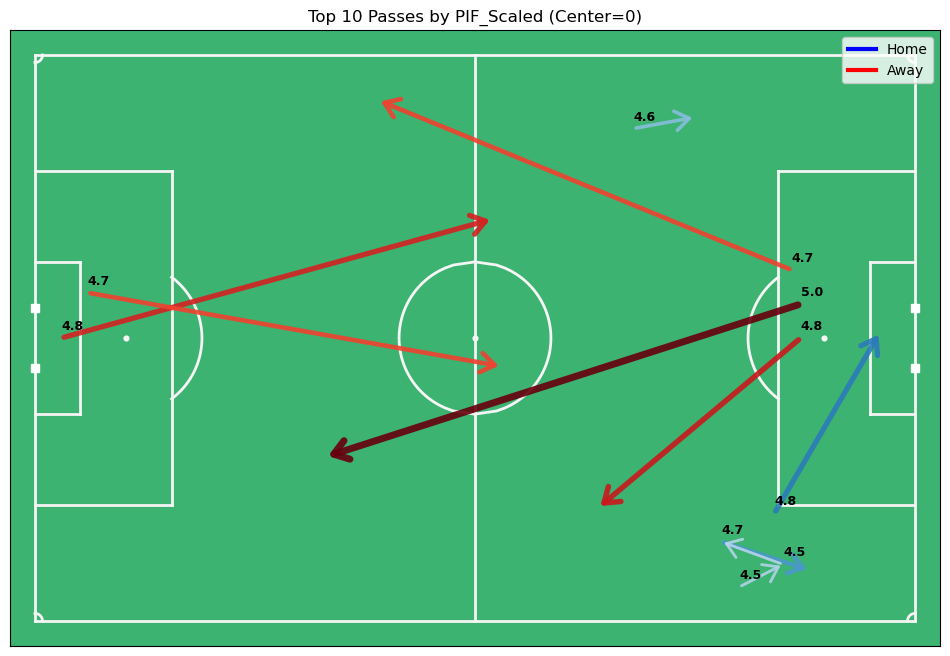

The following graph shows the top 10 passes of Game 2 based on the PIF scores.


In [312]:
#Let's see them on the pitch now: The top passes of game 2 based on our definition of PIF.
import matplotlib.cm as cm

# Plot pitch (centered at 0)
fig, ax = mviz.plot_pitch()
ax.set_title("Top 10 Passes by PIF_Scaled (Center=0)")

# Colormaps
cmap_home = cm.get_cmap('Blues')
cmap_away = cm.get_cmap('Reds')

# Get min/max for normalization
min_pif, max_pif = top_passes['PIF_Scaled'].min(), top_passes['PIF_Scaled'].max()

#Plot arrows(Arrows width and color chnge based on PIF score in sequence)
for _, row in top_passes.iterrows():
    norm_pif = 0.3 + 0.7 * (row['PIF_Scaled'] - min_pif) / (max_pif - min_pif)
    lw = 2 + 3 * ((row['PIF_Scaled'] - min_pif) / (max_pif - min_pif))
    color = cmap_home(norm_pif) if row['Team']=='Home' else cmap_away(norm_pif)

    ax.annotate("",
                xy=(row['End X'], row['End Y']),
                xytext=(row['Start X'], row['Start Y']),
                arrowprops=dict(arrowstyle="->,head_length=1,head_width=0.7",
                                color=color, lw=lw, alpha=0.9),
                annotation_clip=False)

    ax.text(row['Start X'], row['Start Y']+1, f"{row['PIF_Scaled']:.1f}", 
            color='black', fontsize=9, weight='bold')

# Legend
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()
print("The following graph shows the top 10 passes of Game 2 based on the PIF scores.")

In [313]:
#Let's look at the worst passes of game 2 based on our definition of PIF.

# Sort passes by PIF_Scaled ascending (lowest first)
worst = passes_filtered.sort_values('PIF_Scaled', ascending=True)

# Keep worst 10 passes
worst_passes = worst.head(10)

# Display 
worst_passes = worst_passes[['Team', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y', 'PIF_Raw', 'PIF_Scaled']]
worst_passes




,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
903,Home,Player14,Player13,-1.06,-29.92,-1.06,-22.44,0.0,1.0
276,Away,Player21,Player20,-15.90,-19.04,-15.90,-9.52,0.0,1.0
460,Home,Player8,Player4,0.00,2.72,0.00,-11.56,0.0,1.0
603,Home,Player6,Player5,-11.66,6.80,-11.66,-4.08,0.0,1.0
333,Away,Player21,Player17,-5.30,-10.20,-5.30,11.56,0.0,1.0
37,Home,Player6,Player9,-10.60,15.64,-10.60,21.08,0.0,1.0
613,Home,Player4,Player6,13.78,29.24,13.78,14.96,0.0,1.0
932,Home,Player13,Player5,0.00,-13.60,0.00,-6.12,0.0,1.0
825,Home,Player1,Player13,16.96,-26.52,16.96,-20.40,0.0,1.0
700,Home,Player5,Player6,13.78,-26.52,13.78,-16.32,0.0,1.0


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/904859414.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap('Blues')
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/904859414.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap('Reds')


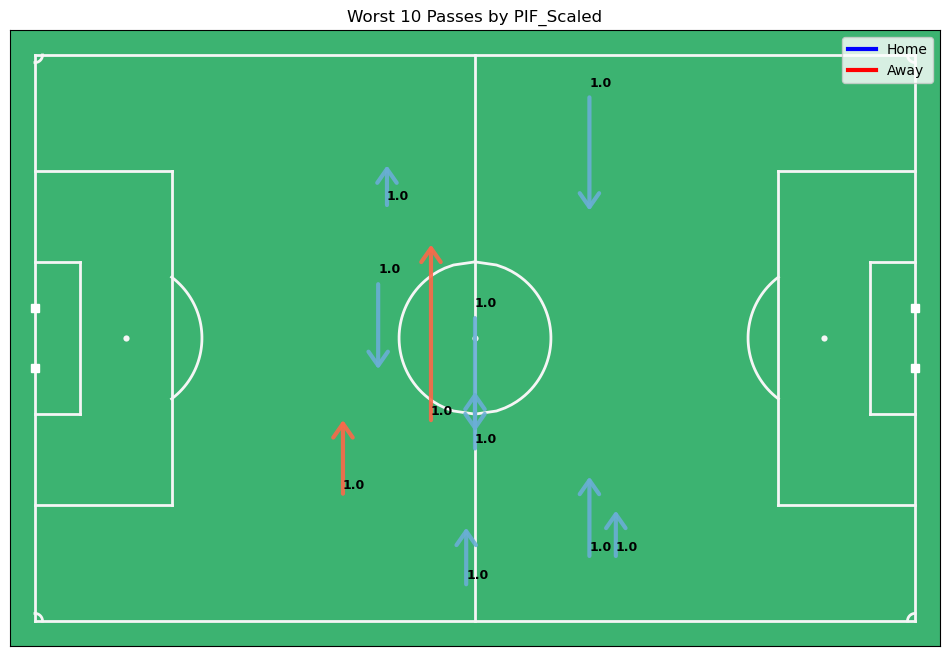

The following graph shows the worst 10 passes of Game 2 based on the PIF scores.


In [314]:
#Let's see them on the pitch now: The worst passes of game 2 based on our definition of PIF.

# Plot pitch (centered at 0)
fig, ax = mviz.plot_pitch()
ax.set_title("Worst 10 Passes by PIF_Scaled")

# Colormaps
cmap_home = cm.get_cmap('Blues')
cmap_away = cm.get_cmap('Reds')

# Get min/max for normalization
min_pif, max_pif = worst_passes['PIF_Scaled'].min(), worst_passes['PIF_Scaled'].max()

#Plot arrows(Arrows width and color chnge based on PIF score in sequence)
for _, row in worst_passes.iterrows():
    # Normalize for color and line width
    if max_pif != min_pif:
        norm_pif = 0.3 + 0.7 * (row['PIF_Scaled'] - min_pif) / (max_pif - min_pif)
        lw = 2 + 3 * ((row['PIF_Scaled'] - min_pif) / (max_pif - min_pif))
    else:
        norm_pif = 0.5  # middle value if all equal
        lw = 3          # default line width

    color = cmap_home(norm_pif) if row['Team'] == 'Home' else cmap_away(norm_pif)

    ax.annotate("",
                xy=(row['End X'], row['End Y']),
                xytext=(row['Start X'], row['Start Y']),
                arrowprops=dict(arrowstyle="->,head_length=1,head_width=0.7",
                                color=color, lw=lw, alpha=0.9),
                annotation_clip=False)

    ax.text(row['Start X'], row['Start Y']+1,
            f"{row['PIF_Scaled']:.1f}",
            color='black', fontsize=9, weight='bold')

#Legend 
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()
print("The following graph shows the worst 10 passes of Game 2 based on the PIF scores.")

In [315]:
#Let's now consider pass sequences that result in a Goal.
#Note:This does not represent all goals of game 2,solely those that are a result of passing.

# Identify goals
goals = events[(events["Type"] == "SHOT") & 
               (events["Subtype"].str.contains("GOAL", na=False))].copy()

goals = goals.sort_values(["Period", "Start Frame"]).reset_index(drop=True)
goals["Goal#"] = goals.index + 1  # numbering goals

#Get last 3 passes before each goal
goal_passes = []

for _, goal in goals.iterrows():
    g_period = goal["Period"]
    g_frame = goal["Start Frame"]

    # Get passes from filtered passes (excludes goalkeepers) in the same period
    passes_before = passes_filtered[
    (passes_filtered["Period"] == g_period) &
    (passes_filtered["Start Frame"] < g_frame)
    ].copy()

    # Take the last 3 passes
    last3 = passes_before.tail(3).copy()
    last3["Goal#"] = goal["Goal#"]

    # Number passes relative to goal (3 = farthest, 1 = closest)
    last3["Pass_Number_To_Goal"] = range(len(last3), 0, -1)

    goal_passes.append(last3)

# Merge all goal passes into a table "goal_passes_table"
goal_passes_table = pd.concat(goal_passes, ignore_index=True)


# Keep relevant columns
goal_passes_table = goal_passes_table[[
    "Goal#", "Pass_Number_To_Goal", "Team", "From", "To",
    "Start X", "Start Y", "End X", "End Y",
    "PIF_Raw", "PIF_Scaled"
]].reset_index(drop=True)

#Output
print("The following table shows the data of 3 passes that lead up to goals that were a result of passing sequences.")
print ("The passes are labelled 1-3 in proximity the goal (1=closest,3=farthest):")
print ("\n\n                                     Goal Passes Table")
goal_passes_table




The following table shows the data of 3 passes that lead up to goals that were a result of passing sequences.
The passes are labelled 1-3 in proximity the goal (1=closest,3=farthest):


                                     Goal Passes Table


,Goal#,Pass_Number_To_Goal,Team,From,To,Start X,Start Y,End X,End Y,PIF_Raw,PIF_Scaled
0,1,3,Home,Player8,Player9,-41.34,-24.48,-42.40,-14.96,0.436103,3.492019
1,1,2,Home,Player8,Player1,-28.62,-7.48,-37.10,23.80,0.462029,3.640168
2,1,1,Home,Player1,Player10,-40.28,19.72,-47.70,-3.40,0.458326,3.619004
3,2,3,Away,Player21,Player19,2.12,12.92,30.74,-26.52,0.200000,2.142857
4,2,2,Away,Player19,Player23,30.74,-27.20,37.10,-15.64,0.344444,2.968254
5,2,1,Away,Player23,Player24,41.34,-9.52,44.52,2.72,0.322222,2.841270
6,3,3,Home,Player8,Player9,27.56,21.08,36.04,4.08,0.329630,2.883598
7,3,2,Home,Player10,Player8,39.22,8.16,43.46,19.04,0.314815,2.798942
8,3,1,Home,Player8,Player9,46.64,19.72,47.70,-1.36,0.303704,2.735450
9,4,3,Away,Player18,Player19,-24.38,-15.64,-33.92,-26.52,0.366667,3.095238


/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/770714564.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_home = cm.get_cmap("Blues")
/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/770714564.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_away = cm.get_cmap("Reds")


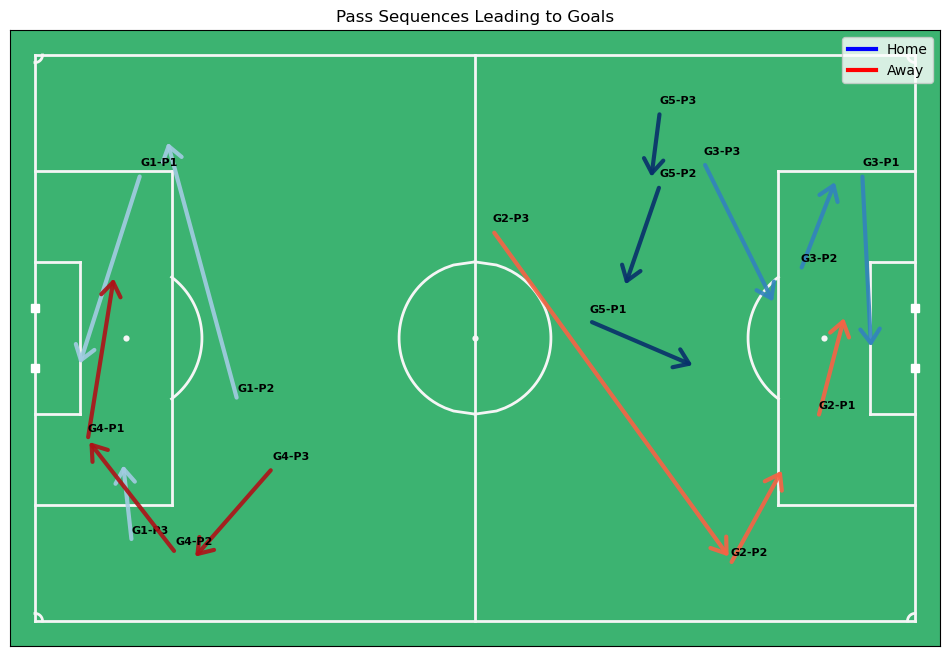

The following visualization of the pitch shows the pass sequences that result in goals.The passes are labelled by goal and pass relative to goal.


In [316]:
#Let's see them on the pitch now: The passes in game 2 that result in a goal.

# Plot pitch
fig, ax = mviz.plot_pitch()
ax.set_title("Pass Sequences Leading to Goals")

cmap_home = cm.get_cmap("Blues")
cmap_away = cm.get_cmap("Reds")

# Loop over goals
for goal_num, group in goal_passes_table.groupby("Goal#"):
    # shading intensity: earlier goals darker, later goals lighter
    norm_shade = 0.2 + 0.8 * (goal_num / goal_passes_table["Goal#"].max())

    for _, row in group.iterrows():
        color = cmap_home(norm_shade) if row["Team"] == "Home" else cmap_away(norm_shade)

        # pass arrows
        ax.annotate(
            "",
            xy=(row["End X"], row["End Y"]),
            xytext=(row["Start X"], row["Start Y"]),
            arrowprops=dict(
                arrowstyle="->,head_length=1,head_width=0.7",
                color=color, lw=3, alpha=0.9,
            ),
            annotation_clip=False,
        )

        # Label pass
        ax.text(
            row["Start X"],
            row["Start Y"] + 1,
            f"G{goal_num}-P{row['Pass_Number_To_Goal']}",
            color="black",
            fontsize=8,
            weight="bold",
        )

        #player trajectory
        tracking = tracking_home if row["Team"] == "Home" else tracking_away

        # get player column name
        player_id = row["From"]
        if player_id in tracking.columns:
            traj = tracking.loc[
                (tracking["Period"] == goals.loc[goal_num-1, "Period"]) &
                (tracking["Time [s]"] >= row["Start Time [s]"]) &
                (tracking["Time [s]"] <= row["End Time [s]"])
            , [f"{player_id}_x", f"{player_id}_y"]]

            ax.plot(traj[f"{player_id}_x"], traj[f"{player_id}_y"],
                    color=color, lw=1.5, alpha=0.6, linestyle="--")

# Legend
handles = [plt.Line2D([0],[0], color='blue', lw=3),
           plt.Line2D([0],[0], color='red', lw=3)]
ax.legend(handles, ['Home', 'Away'], loc='upper right')

plt.show()
print("The following visualization of the pitch shows the pass sequences that result in goals.The passes are labelled by goal and pass relative to goal.")

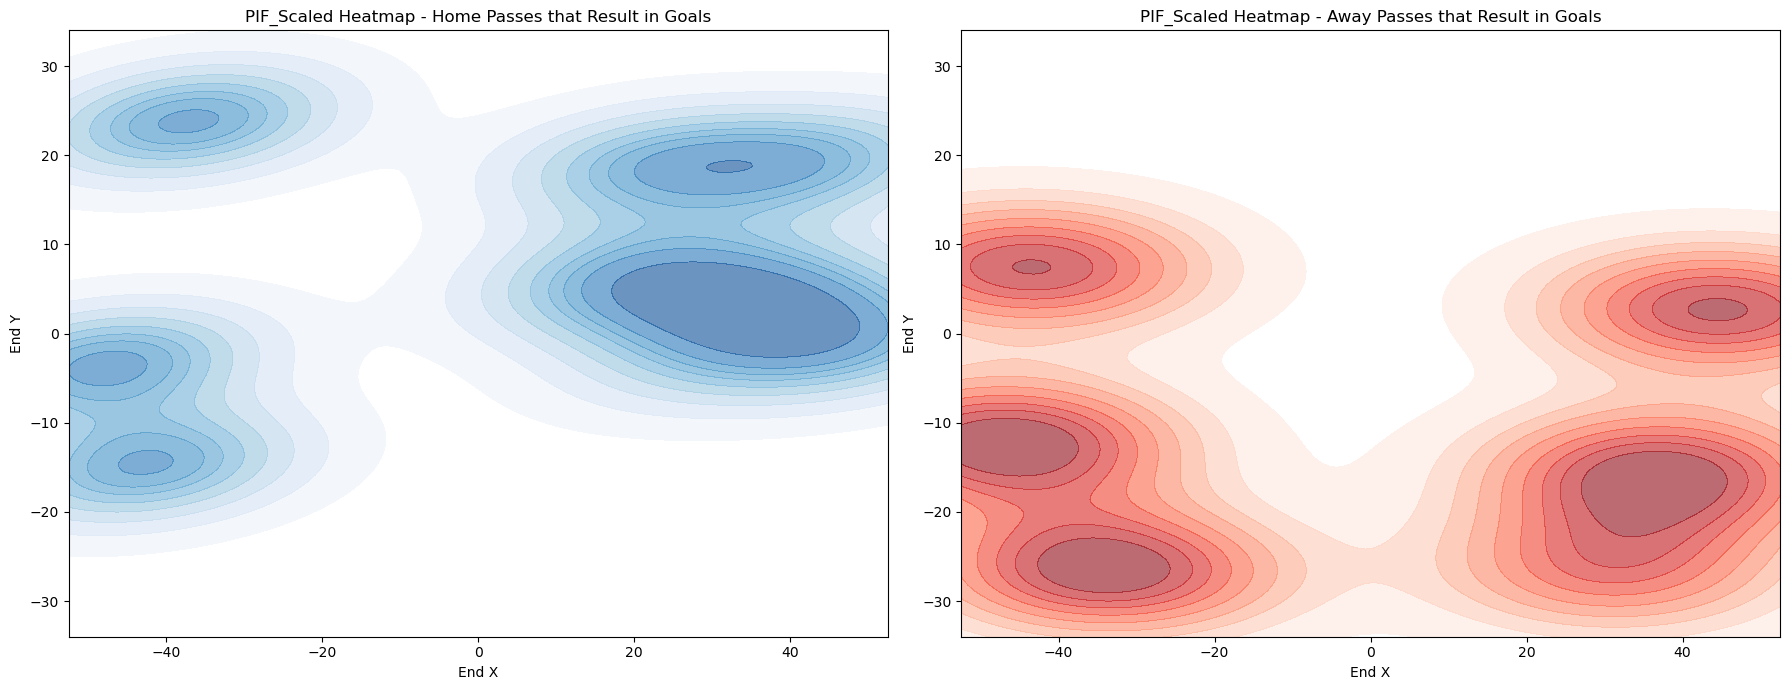

The following heatmaps show where passes with higher PIF values ended that directly led to goals.
Home team is shown in blue shades, Away team in red shades.


In [317]:
#Heat map of passes PIF_Scaled values that lead to Goals

# Setup figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define teams and corresponding colormaps
teams = ["Home", "Away"]
colors = ["Blues", "Reds"]

for ax, team, cmap in zip(axes, teams, colors):
    team_data = goal_passes_table[goal_passes_table["Team"] == team]

    if not team_data.empty:
        sns.kdeplot(
            x=team_data["End X"],
            y=team_data["End Y"],
            weights=team_data["PIF_Scaled"],
            cmap=cmap,
            fill=True,
            alpha=0.6,
            bw_adjust=0.5,
            ax=ax,
            thresh=0.05
        )

    # Set pitch boundaries (Standard soccer pitch size in meters)
    ax.set_xlim(-105/2, 105/2)
    ax.set_ylim(-68/2, 68/2)
    ax.set_title(f"PIF_Scaled Heatmap - {team} Passes that Result in Goals")

plt.tight_layout()
plt.show()

print ( "The following heatmaps show where passes with higher PIF values ended that directly led to goals.\n"
         "Home team is shown in blue shades, Away team in red shades.")


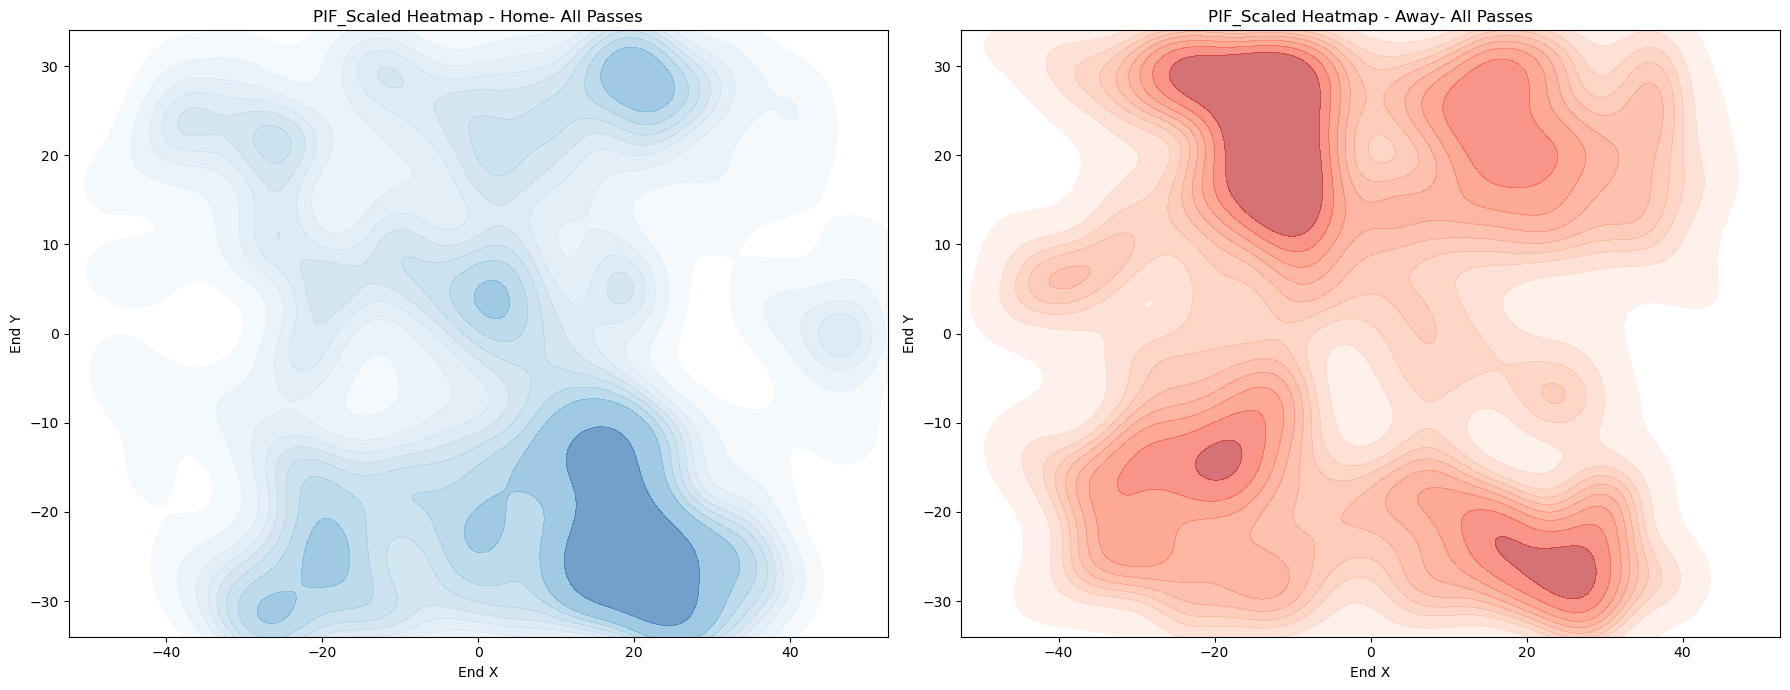

The following heatmaps show all passes PIF values in game 2.
Home team is shown in blue shades, Away team in red shades.


In [318]:
#Heat map of all passes PIF_Scaled values in Game 2

# Setup figure with 2 subplots 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define teams and corresponding colormaps
teams = ["Home", "Away"]
colors = ["Blues", "Reds"]

for ax, team, cmap in zip(axes, teams, colors):
    team_data = passes_filtered[passes_filtered['Team'] == team]

    if not team_data.empty:
        sns.kdeplot(
            x=team_data["End X"],
            y=team_data["End Y"],
            weights=team_data["PIF_Scaled"],
            cmap=cmap,
            fill=True,
            alpha=0.6,
            bw_adjust=0.5,  
            ax=ax,
            thresh=0.05
        )
# Set pitch boundaries (Standard soccer pitch size in meters)
    ax.set_xlim(-105/2, 105/2)
    ax.set_ylim(-68/2, 68/2)
    ax.set_title(f"PIF_Scaled Heatmap - {team}- All Passes")

plt.tight_layout()
plt.show()
print ( "The following heatmaps show all passes PIF values in game 2.\n"
         "Home team is shown in blue shades, Away team in red shades.")

/var/folders/4_/gmhxdy7d0hd60_9jd9__r0pw0000gn/T/ipykernel_50119/4098474424.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


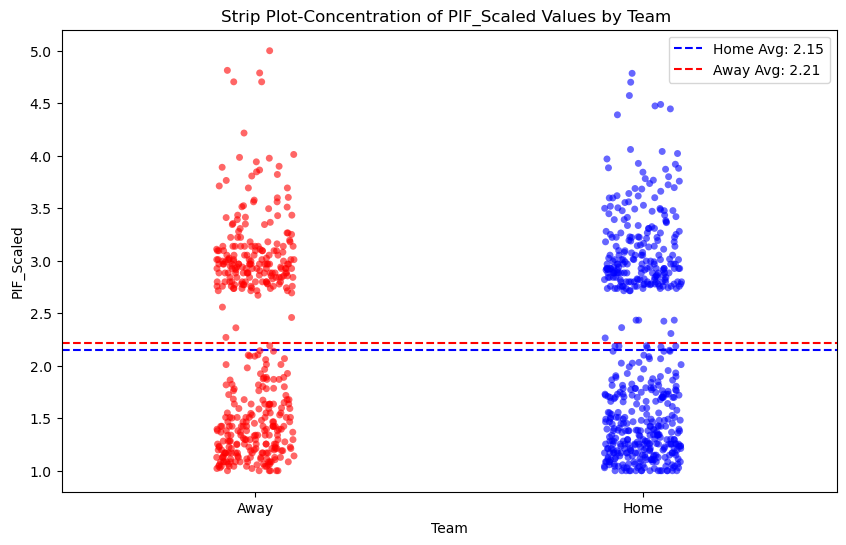

The following strip plot shows the concentration of all PIF_Scaled values in game 2 by team.
The average PIF values for each team is represented by a horizontal line in the respective color.


In [319]:
#Strip plot concentration of all PIF_Scaled values by Team.

#Calculate average PIF_Scaled values for each team
avg_home = passes_filtered[passes_filtered['Team'] == 'Home']['PIF_Scaled'].mean()
avg_away = passes_filtered[passes_filtered['Team'] == 'Away']['PIF_Scaled'].mean()


plt.figure(figsize=(10, 6))

#Plot individual pass PIF_Scaled values by team as scattered points
sns.stripplot(
    x='Team',
    y='PIF_Scaled',
    data=passes_filtered,
    jitter=True,
    palette={'Home': 'blue', 'Away': 'red'},
    alpha=0.6
)

#Averages as horizontal lines
plt.axhline(avg_home, color='blue', linestyle='--', label=f'Home Avg: {avg_home:.2f}')
plt.axhline(avg_away, color='red', linestyle='--', label=f'Away Avg: {avg_away:.2f}')

#Plot labels and title
plt.title('Strip Plot-Concentration of PIF_Scaled Values by Team ')
plt.ylabel('PIF_Scaled')
plt.xlabel('Team')
plt.legend()

#Output 
plt.show()
print("The following strip plot shows the concentration of all PIF_Scaled values in game 2 by team.\nThe average PIF values for each team is represented by a horizontal line in the respective color.")


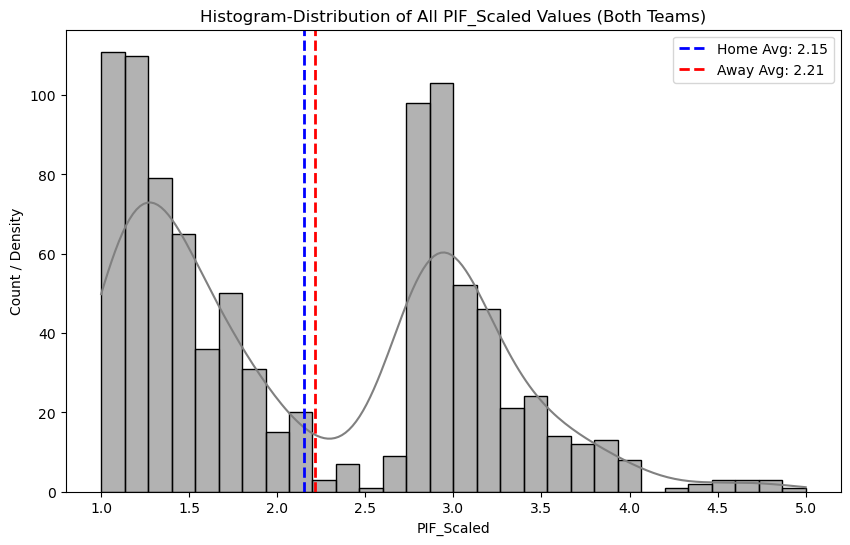

The following histogram shows the distribution of all PIF_Scaled values in game 2.
The average PIF values for each team is represented by a horizontal line in the respective color.


In [320]:
#Histogram distribution for all passes in game 2

plt.figure(figsize=(10, 6))

# Single distribution for all passes
sns.histplot(passes_filtered['PIF_Scaled'], bins=30, kde=True, color='grey', alpha=0.6)

# Overlay team averages
plt.axvline(avg_home, color='blue', linestyle='--', linewidth=2, label=f'Home Avg: {avg_home:.2f}')
plt.axvline(avg_away, color='red', linestyle='--', linewidth=2, label=f'Away Avg: {avg_away:.2f}')

#Plot labels and title
plt.title('Histogram-Distribution of All PIF_Scaled Values (Both Teams)')
plt.xlabel('PIF_Scaled')
plt.ylabel('Count / Density')
plt.legend()

#Output 
plt.show()
print ("The following histogram shows the distribution of all PIF_Scaled values in game 2.\nThe average PIF values for each team is represented by a horizontal line in the respective color.")


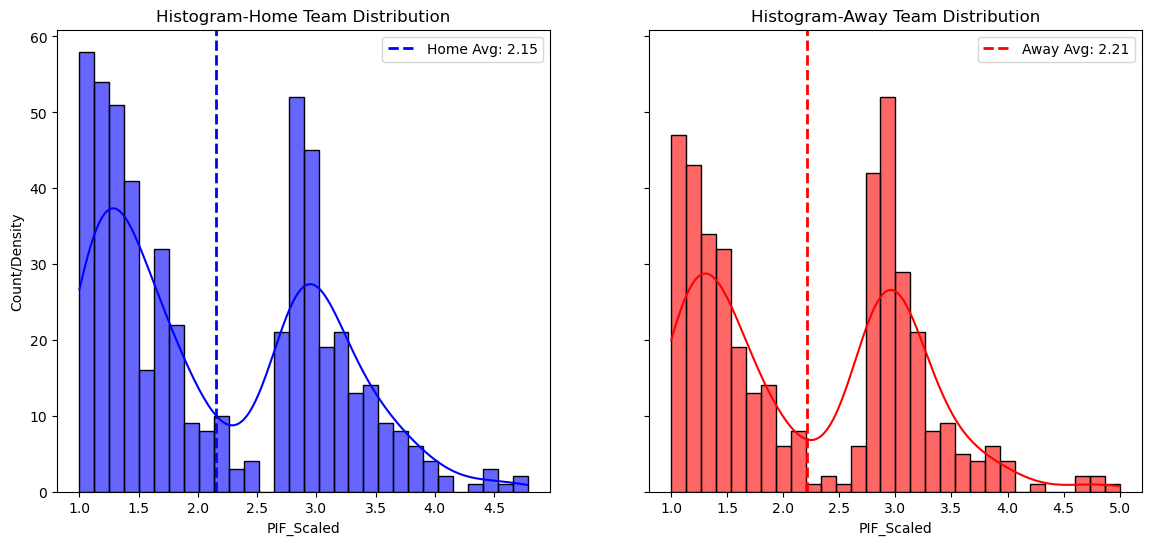

The following histograms shows the distribution of all PIF_Scaled values in game2 seperated by team.
The average PIF values for each team is represented by a horizontal line.


In [321]:
#Histogram distribution for all passes in game 2:Seperated by team.

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 2 distributions:Home & Away

#Home team histogram distribution
sns.histplot(
    passes_filtered[passes_filtered['Team'] == 'Home']['PIF_Scaled'],
    bins=30, kde=True, color='blue', alpha=0.6, ax=axes[0]
)
#Plot average,labels and title
axes[0].axvline(avg_home, color='blue', linestyle='--', linewidth=2, label=f'Home Avg: {avg_home:.2f}')
axes[0].set_title('Histogram-Home Team Distribution')
axes[0].set_xlabel('PIF_Scaled')
axes[0].set_ylabel('Count/Density')
axes[0].legend()

#Away team histogram distribution
sns.histplot(
    passes_filtered[passes_filtered['Team'] == 'Away']['PIF_Scaled'],
    bins=30, kde=True, color='red', alpha=0.6, ax=axes[1]
)
#Plot average,labels and title
axes[1].axvline(avg_away, color='red', linestyle='--', linewidth=2, label=f'Away Avg: {avg_away:.2f}')
axes[1].set_title('Histogram-Away Team Distribution')
axes[1].set_xlabel('PIF_Scaled')
axes[1].set_ylabel('Count/Density')
axes[1].legend()


#Output
plt.show()
print ("The following histograms shows the distribution of all PIF_Scaled values in game2 seperated by team.\nThe average PIF values for each team is represented by a horizontal line.")
